<a href="https://colab.research.google.com/github/ethxng/Transformed-based-Git-Commit-Classification/blob/main/nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data pre-processing

In [ ]:
import nbformat
nb = nbformat.read("/content/drive/MyDrive/CS533: NLP/NLP.ipynb", as_version=nbformat.NO_CONVERT)
if "widgets" in nb.metadata:
    del nb.metadata["widgets"]
nbformat.write(nb, "NLP.ipynb")

## Load Dataset

In [ ]:
import pandas as pd

splits = {'train': 'train.csv', 'validation': 'val.csv', 'test': 'test.csv'}
train_df = pd.read_csv("hf://datasets/Maxscha/commitbench/" + splits["train"])
val_df = pd.read_csv("hf://datasets/Maxscha/commitbench/" + splits["validation"])
test_df = pd.read_csv("hf://datasets/Maxscha/commitbench/" + splits["test"])

# Inspection

In [ ]:
len(train_df)

1165213

In [ ]:
len(test_df)

249688

In [ ]:
import re

# Extract all words at the start of the message followed by ( or :
# The regex matches alphanumeric characters at the start of the string
all_prefixes = test_df['message'].str.extract(r'^(\w+)[\\(:]', flags=re.IGNORECASE, expand=False).dropna().str.lower()

# Get unique values and sort them
unique_prefixes = sorted(all_prefixes.unique())

print(f"Found {len(unique_prefixes)} unique starting words.")
print(unique_prefixes)

Found 4595 unique starting words.
['__construct', '__init__', '__main__', '__set', '__str__', '__tostring', '__unicode__', '_analyse_function_features', '_arbitraryitemformatter', '_exclusivelock', '_fast_memory_load', '_filefaker', '_formatname', '_generate_filespecs', '_get_config_list', '_get_credentials', '_get_player_stats', '_get_process_output', '_idle', '_include', '_op_info_transaction', '_parse_block', '_rlcompleter', '_section_execution_order', '_send', '_set_main_color', '_tokenize', '_unique', '_write_content_file', 'a', 'a2s_info', 'aafig', 'aax', 'abortif', 'abortspec', 'aboutdialog', 'abstractcardrequest', 'abstractgoogleasyncwritechannel', 'abstractmultipleoptionsbasetablepanel', 'abstractparser', 'abstractproperty', 'abstractrector', 'abstractrequesthandler', 'abstractsmalldbrepository', 'abstractstreamex', 'abstractuploadedfile', 'ac', 'acceptance', 'accesibility', 'access', 'accesscontrol', 'accesscontrolextension', 'accessibility', 'accesslib', 'accesslog', 'accoun

In [ ]:
# Calculate frequency of all starting words found in 'word(' or 'word:' format
prefix_distribution = all_prefixes.value_counts()

# Filter for those with more than 100 occurrences
common_prefixes = prefix_distribution[prefix_distribution > 100]

print(f"Found {len(common_prefixes)} categories with more than 500 occurrences:")
print(common_prefixes)

Found 21 categories with more than 500 occurrences:
message
fix         6244
chore       1139
feat        1098
test        1071
refactor     969
bugfix       839
docs         410
tests        409
bug          283
fixed        232
doc          191
task         172
maint        168
core         161
enh          149
tst          126
build        121
style        121
minor        114
feature      114
server       112
Name: count, dtype: int64


In [ ]:
train_df[train_df['message'].str.startswith("feature:", na=False)]['message']

,message
15198,feature: allow the unique number for a CanDevi...
19768,feature: added shorthand for start command out...
22073,"feature: add method ""register"" to Tags class"
26879,feature: finalize version <I>
35091,feature: check download path access on server ...
...,...
1157023,feature: OutputHTML allow node itself output o...
1157743,feature: controller of Laravel 5
1159801,feature: remove `ScidAliasOptional` dependency...
1162835,feature: only output icon wrapper span when sl...


## Pre-processing Pipeline

In [ ]:
import pandas as pd
import re

def clean_noise(text):
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove GitHub Issue References (e.g., #123)
    text = re.sub(r'#\d+', '', text)
    # Remove Hexadecimal Commit Hashes
    text = re.sub(r'\b[0-9a-f]{7,40}\b', '', text)

    text = re.sub(r'\(?#\s*(\d+|<i>)\)?', '', text)
    # Remove extra whitespace left behind
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_commits(df, threshold):
    # 8) Handle lower/uppercase
    df['message'] = df['message'].astype(str).str.lower()

    # 1a) Extract tag
    df['extracted_tag'] = df['message'].str.extract(r'^([a-z0-9]+)[\(:]')
    df = df.dropna(subset=['extracted_tag'])

    # 1b) Filter by value count (>= 500)
    counts = df['extracted_tag'].value_counts()
    valid_tags = counts[counts >= threshold].index
    df = df[df['extracted_tag'].isin(valid_tags)].copy()

    # 2) Drop specific noisy words
    exclude_list = ['core', 'task', 'minor', 'build']
    df = df[~df['extracted_tag'].isin(exclude_list)]

    # 4 & 6) Maintain original tag
    df['original_tag'] = df['extracted_tag']

    # 3 & 5) Merge categories
    label_map = {
        'fix': 'fix', 'bugfix': 'fix', 'fixed': 'fix', 'bug': 'fix',
        'docs': 'doc', 'doc': 'doc',
        'maint': 'chore', 'chore': 'chore',
        'enh': 'feat', 'feat': 'feat',
        'test': 'test', 'tests': 'test', 'tst': 'test',
        'refactor': 'refactor'
    }
    df['result_class'] = df['original_tag'].map(label_map)
    df = df.dropna(subset=['result_class'])

    # 7) Strip the first word and punctuation
    # FIX: Removed 'count=1' which caused the TypeError
    df['message'] = df['message'].str.replace(r'^[a-z0-9]+(\([^\)]*\))?[:]', '', regex=True)

    # Advanced Noise Filtering
    df['message'] = df['message'].apply(clean_noise)

    # Length-Based Pruning (Threshold = 3 words)
    df = df[df['message'].str.split().str.len() >= 3]

    return df[['message', 'result_class', 'original_tag']]

# Execute
train_df_processed = preprocess_commits(train_df, 500)

train_df_processed[:10]

len(train_df_processed)

# Calculate the distribution of the result_class labels
final_distribution = train_df_processed['result_class'].value_counts()

print("Distribution of processed labels (result_class):")
display(final_distribution)

train_df_processed[train_df_processed['message'].str.startswith("task", na=False)]

"""Saving training dataset"""

#train_df_processed.to_csv('/content/drive/MyDrive/CS533: NLP/training_dataset.csv', index=False)

test_df_processed = preprocess_commits(test_df, 190)

len(train_df_processed)

# Calculate the distribution of the result_class labels
final_distribution = test_df_processed['result_class'].value_counts()

print(f"Length of test set: {len(test_df_processed)}")
print("Distribution of processed labels (result_class):")
display(final_distribution)

Distribution of processed labels (result_class):


,count
result_class,
fix,34238
test,7158
feat,5881
chore,5670
refactor,4621
doc,2742


Length of test set: 0
Distribution of processed labels (result_class):


,count
result_class,


In [ ]:
train_df_processed[:10]

,message,result_class,original_tag
1,reduce server count when destroyed,refactor,refactor
22,get rid of newly appeared eslint errors,refactor,refactor
26,"chore(deepword) rm "" """,chore,chore
51,add setresponse method.,refactor,refactor
68,focus location input for typing when 'x' press...,feat,feat
86,timeline with colors option,fix,bugfix
104,add test for non-number maxage,test,tests
162,fixed an edge case where no pagestodisplay val...,fix,bugfix
180,add re-export of gtm logout and flopflip,feat,feat
218,execute the precommit scripts when directory n...,fix,fix


In [ ]:
len(train_df_processed)

60310

In [ ]:
# Calculate the distribution of the result_class labels
final_distribution = train_df_processed['result_class'].value_counts()

print("Distribution of processed labels (result_class):")
display(final_distribution)

Distribution of processed labels (result_class):


,count
result_class,
fix,34238
test,7158
feat,5881
chore,5670
refactor,4621
doc,2742


In [ ]:
train_df_processed[train_df_processed['message'].str.startswith("task", na=False)]

,message,result_class,original_tag
268275,"tasks can be added multiple times, ignore thos...",fix,fix
269824,task logs performance regression,fix,fix
286025,task scheduler test uses a fixed time * fix: t...,fix,fix
372713,task never finishing when no src files process...,fix,fix
561836,task terminated status on windows,fix,fix
570028,task execution will accurately measure queue d...,feat,feat
570984,task arg deduplication with =,fix,fix
694703,task lookup for all tasks will now skip the af...,fix,fix
702288,tasks should actually load 🙈,fix,fix
716799,task worker requeue wrong task. fixes,fix,fix


## Saving training dataset

In [ ]:
#train_df_processed.to_csv('/content/drive/MyDrive/CS533: NLP/training_dataset.csv', index=False)


In [ ]:
test_df_processed = preprocess_commits(test_df, 190)

In [ ]:
len(train_df_processed)

60310

In [ ]:
# Calculate the distribution of the result_class labels
final_distribution = test_df_processed['result_class'].value_counts()

print(f"Length of test set: {len(test_df_processed)}")
print("Distribution of processed labels (result_class):")
display(final_distribution)

In [ ]:
test_df_processed.to_csv('/content/drive/MyDrive/CS533: NLP/test_dataset.csv', index=False)

# TF-IDF + Logistic Regression

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
train_df = pd.read_csv('/content/drive/MyDrive/CS533: NLP/training_dataset.csv')
val_df = pd.read_csv('/content/drive/MyDrive/CS533: NLP/validation_dataset.csv')
test_df = pd.read_csv('/content/drive/MyDrive/CS533: NLP/test_dataset.csv')

In [ ]:
len(val_df)

12664

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# 1. Define the Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),    # Captures unigrams and bigrams
        max_features=10000,    # Keeps the 10k most important words to prevent bloat
        stop_words='english'   # Removes 'the', 'is', 'at', etc.
    )),
    ('clf', LogisticRegression(
        class_weight='balanced', # address class imbalance
        max_iter=1000,
        random_state=42
    ))
])

# 2. Train the Model
# X = message column, y = result_class column
pipeline.fit(train_df['message'], train_df['result_class'])

# 3. Predict on Test Set
y_pred = pipeline.predict(test_df['message'])

# 4. Evaluate
print(classification_report(test_df['result_class'], y_pred))

              precision    recall  f1-score   support

       chore       0.31      0.41      0.35      1085
         doc       0.37      0.66      0.48       579
        feat       0.31      0.56      0.40      1068
         fix       0.85      0.52      0.65      7423
    refactor       0.24      0.51      0.33       857
        test       0.51      0.61      0.56      1442

    accuracy                           0.53     12454
   macro avg       0.43      0.54      0.46     12454
weighted avg       0.65      0.53      0.56     12454



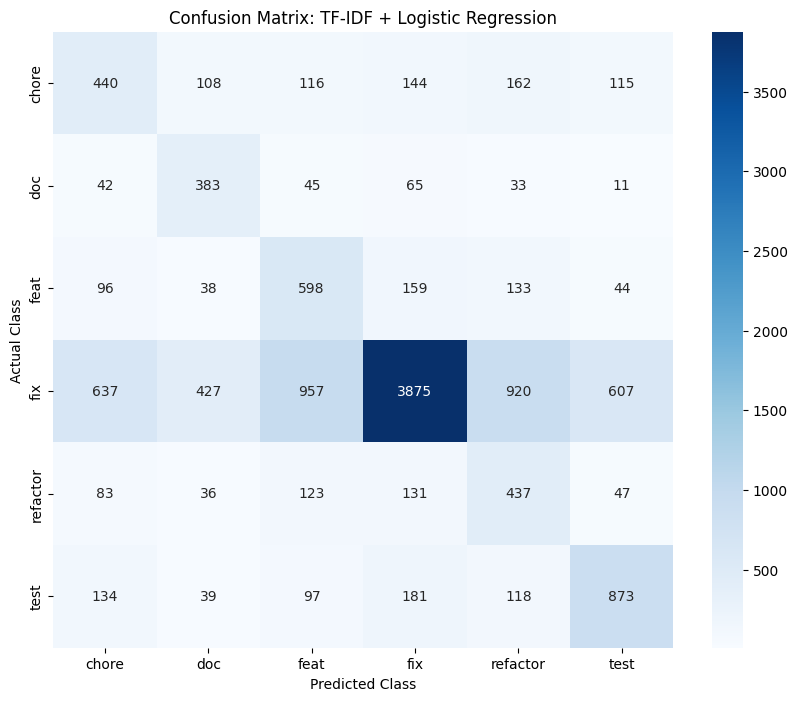

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Define the labels in alphabetical order
labels = ['chore', 'doc', 'feat', 'fix', 'refactor', 'test']

# 2. Create Confusion Matrix
# y_test = test_df['result_class']
# y_pred = The predictions from your model
cm = confusion_matrix(test_df['result_class'], y_pred, labels=labels)

# 3. Plot using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',            # Format as integers
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.title('Confusion Matrix: TF-IDF + Logistic Regression')
plt.show()

In [ ]:
# 1. Create test messages
my_queries = [
    "fix null pointer exception in login",
    "add new user profile page",
    "update readme with installation guide",
    "clean up whitespace",
    "refactor authentication logic",
    "oops",
    "init commit",
    "initial commit"
]

# 2. Get the predicted class
predictions = pipeline.predict(my_queries)

# 3. Get the probability for each class
probs = pipeline.predict_proba(my_queries)

# 4. Print the results
print(f"{'Message':<40} | {'Prediction':<10} | {'Confidence'}")
print("-" * 70)

for i, message in enumerate(my_queries):
    pred_class = predictions[i]
    confidence = max(probs[i]) * 100  # Take the highest probability
    print(f"{message:<40} | {pred_class:<10} | {confidence:.1f}%")

Message                                  | Prediction | Confidence
----------------------------------------------------------------------
fix null pointer exception in login      | fix        | 67.9%
add new user profile page                | feat       | 80.5%
update readme with installation guide    | doc        | 83.8%
clean up whitespace                      | chore      | 47.3%
refactor authentication logic            | refactor   | 58.0%
oops                                     | test       | 32.5%
init commit                              | fix        | 37.5%
initial commit                           | chore      | 36.9%


 # Baseline CodeBERT


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
import torch

In [ ]:
train_df = pd.read_csv('/content/drive/MyDrive/CS533: NLP/training_dataset.csv')
val_df = pd.read_csv('/content/drive/MyDrive/CS533: NLP/validation_dataset.csv')
test_df = pd.read_csv('/content/drive/MyDrive/CS533: NLP/test_dataset.csv')

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Model configuration
MODEL_NAME = "microsoft/codebert-base"
MAX_LENGTH = 128  # Most commit messages are short
BATCH_SIZE = 16
LEARNING_RATE = 3e-5
NUM_EPOCHS = 3

In [ ]:
# Create label mappings
unique_labels = sorted(train_df['result_class'].unique())
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print(f"\nLabel mapping:")
for label, idx in label2id.items():
    print(f"  {label}: {idx}")


Label mapping:
  chore: 0
  doc: 1
  feat: 2
  fix: 3
  refactor: 4
  test: 5


In [ ]:
# Convert labels to integers
train_df['label'] = train_df['result_class'].map(label2id)
val_df['label'] = val_df['result_class'].map(label2id)

print(f"\nDataset sizes:")
print(f"  Train: {len(train_df)}")
print(f"  Validation: {len(val_df)}")


Dataset sizes:
  Train: 60310
  Validation: 12664


Tokenization

In [ ]:
print(f"\nLoading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    """Tokenize the commit messages"""
    return tokenizer(
        examples['message'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )


Loading tokenizer: microsoft/codebert-base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
# Convert pandas dataframes to HuggingFace datasets
train_dataset = Dataset.from_pandas(train_df[['message', 'label']])
val_dataset = Dataset.from_pandas(val_df[['message', 'label']])

# Apply tokenization
print("Tokenizing datasets...")
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

Tokenizing datasets...


Map:   0%|          | 0/60310 [00:00<?, ? examples/s]

Map:   0%|          | 0/12664 [00:00<?, ? examples/s]

In [ ]:
print(f"\nLoading model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)


Loading model: microsoft/codebert-base


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Compute metrics

In [ ]:
def compute_metrics(eval_pred):
    """Compute accuracy, precision, recall, and F1"""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Overall accuracy
    accuracy = accuracy_score(labels, predictions)

    # Per-class precision, recall, F1 (macro average)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average='macro',
        zero_division=0
    )

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_dir='./logs',
    logging_steps=50,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
print("Starting training...")

trainer.train()

Starting training...


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.944679,0.933598,0.677432,0.574701,0.490345,0.510558
2,0.863564,0.913921,0.683907,0.575259,0.524866,0.543729
3,0.673929,0.956408,0.684302,0.573824,0.532059,0.548664


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=11310, training_loss=0.8489305980641899, metrics={'train_runtime': 4126.0561, 'train_samples_per_second': 43.851, 'train_steps_per_second': 2.741, 'total_flos': 1.190159823481344e+16, 'train_loss': 0.8489305980641899, 'epoch': 3.0})

In [ ]:
print("\nSaving model to /content/drive/MyDrive/CS525")
model.save_pretrained('/content/drive/MyDrive/CS525')
tokenizer.save_pretrained('/content/drive/MyDrive/CS525')

print("\nDone!")


Saving model to /content/drive/MyDrive/CS525


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Done!


In [ ]:
print("Evaluating on validation set...")
# test_df['label'] = test_df['result_class'].map(label2id)
# test_dataset = Dataset.from_pandas(test_df[['message', 'label']])

# Get predictions
predictions_output = trainer.predict(val_dataset)
predictions = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids

# Overall metrics
print("\nOverall Metrics:")
print(f"  Accuracy: {accuracy_score(true_labels, predictions):.4f}")

precision, recall, f1, support = precision_recall_fscore_support(
    true_labels,
    predictions,
    average='macro',
    zero_division=0
)
print(f"  Macro Precision: {precision:.4f}")
print(f"  Macro Recall: {recall:.4f}")
print(f"  Macro F1: {f1:.4f}")

# Per-class metrics
print("\nPer-Class Metrics:")
print(classification_report(
    true_labels,
    predictions,
    target_names=[id2label[i] for i in range(len(id2label))],
    digits=4,
    zero_division=0
))

# CodeBERT with Inverse Class Frequency (class imbalance)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
import torch

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

MODEL_NAME = "microsoft/codebert-base"
MAX_LENGTH = 128
BATCH_SIZE = 16
LEARNING_RATE = 3e-5
NUM_EPOCHS = 3

Using device: cuda


In [ ]:
train_df = pd.read_csv('/content/drive/MyDrive/CS533: NLP/training_dataset.csv')
val_df = pd.read_csv('/content/drive/MyDrive/CS533: NLP/validation_dataset.csv')
test_df = pd.read_csv('/content/drive/MyDrive/CS533: NLP/test_dataset.csv')

In [ ]:
# Create label mappings
unique_labels = sorted(train_df['result_class'].unique())
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print(f"\nLabel mapping:")
for label, idx in label2id.items():
    print(f"  {label}: {idx}")

# Convert labels to integers
train_df['label'] = train_df['result_class'].map(label2id)
val_df['label'] = val_df['result_class'].map(label2id)


Label mapping:
  chore: 0
  doc: 1
  feat: 2
  fix: 3
  refactor: 4
  test: 5


In [ ]:
# CALCULATE INVERSE CLASS FREQUENCY WEIGHTS
# Count frequency of each class in training set
class_counts = train_df['result_class'].value_counts()
print(f"\nClass distribution in training set:")
for label in unique_labels:
    count = class_counts.get(label, 0)
    print(f"  {label}: {count}")

# Calculate inverse frequencies: w_c = 1 / f_c
# f_c is the frequency of class c
total_samples = len(train_df)
class_weights = {}

for label in unique_labels:
    count = class_counts.get(label, 0)
    frequency = count / total_samples  # f_c
    weight = 1.0 / frequency if frequency > 0 else 0.0  # w_c = 1/f_c
    class_weights[label] = weight

print(f"\nInverse Class Frequency weights:")
for label in unique_labels:
    print(f"  {label}: {class_weights[label]:.4f}")

# Convert to tensor in the correct order (by label id)
class_weights_tensor = torch.tensor(
    [class_weights[id2label[i]] for i in range(len(id2label))],
    dtype=torch.float32
).to(device)

print(f"\nClass weights tensor: {class_weights_tensor}")

print(f"\nDataset sizes:")
print(f"  Train: {len(train_df)}")
print(f"  Validation: {len(val_df)}")



Class distribution in training set:
  chore: 5670
  doc: 2742
  feat: 5881
  fix: 34238
  refactor: 4621
  test: 7158

Inverse Class Frequency weights:
  chore: 10.6367
  doc: 21.9949
  feat: 10.2551
  fix: 1.7615
  refactor: 13.0513
  test: 8.4255

Class weights tensor: tensor([10.6367, 21.9949, 10.2551,  1.7615, 13.0513,  8.4255], device='cuda:0')

Dataset sizes:
  Train: 60310
  Validation: 12664


In [ ]:
print(f"\nLoading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    """Tokenize the commit messages"""
    return tokenizer(
        examples['message'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

# Convert to HuggingFace datasets
train_dataset = Dataset.from_pandas(train_df[['message', 'label']])
val_dataset = Dataset.from_pandas(val_df[['message', 'label']])

# Apply tokenization
print("Tokenizing datasets...")
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])


Loading tokenizer: microsoft/codebert-base
Tokenizing datasets...


Map:   0%|          | 0/60310 [00:00<?, ? examples/s]

Map:   0%|          | 0/12664 [00:00<?, ? examples/s]

In [ ]:
# 5. CUSTOM TRAINER WITH WEIGHTED LOSS

class WeightedLossTrainer(Trainer):
    """
    Custom Trainer that applies class weights to the loss function
    """
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """
        Override compute_loss to apply class weights
        """
        labels = inputs.pop("labels")

        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Compute weighted cross-entropy loss
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

In [ ]:
print(f"\nLoading model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)


Loading model: microsoft/codebert-base


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(eval_pred):
    """Compute accuracy, precision, recall, and F1"""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average='macro',
        zero_division=0
    )

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [ ]:
training_args = TrainingArguments(
    output_dir='./results_weighted',
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_dir='./logs_weighted',
    logging_steps=50,
    report_to='none',
)

# Use custom trainer with class weights
trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor,
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
print("Starting training with Inverse Class Frequency weighting...")

trainer.train()

Starting training with Inverse Class Frequency weighting...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.204814,1.202338,0.570831,0.467867,0.567061,0.496348
2,1.105956,1.176351,0.570594,0.476086,0.583132,0.507246
3,0.853294,1.250701,0.577780,0.478658,0.580585,0.509410


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=11310, training_loss=1.0894528385604196, metrics={'train_runtime': 4130.4401, 'train_samples_per_second': 43.804, 'train_steps_per_second': 2.738, 'total_flos': 1.190159823481344e+16, 'train_loss': 1.0894528385604196, 'epoch': 3.0})

In [ ]:
model.save_pretrained('/content/drive/MyDrive/CS533: NLP')
tokenizer.save_pretrained('/content/drive/MyDrive/CS533: NLP')

print("\nDone!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Done!


In [ ]:
# EVALUATE ON VALIDATION SET

print("Evaluating on validation set...")

predictions_output = trainer.predict(val_dataset)
predictions = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids

# Overall metrics
print("\nOverall Metrics:")
print(f"  Accuracy: {accuracy_score(true_labels, predictions):.4f}")

precision, recall, f1, support = precision_recall_fscore_support(
    true_labels,
    predictions,
    average='macro',
    zero_division=0
)
print(f"  Macro Precision: {precision:.4f}")
print(f"  Macro Recall: {recall:.4f}")
print(f"  Macro F1: {f1:.4f}")

# Per-class metrics
print("\nPer-Class Metrics:")
print(classification_report(
    true_labels,
    predictions,
    target_names=[id2label[i] for i in range(len(id2label))],
    digits=4,
    zero_division=0
))

Evaluating on validation set...



Overall Metrics:
  Accuracy: 0.5778
  Macro Precision: 0.4787
  Macro Recall: 0.5806
  Macro F1: 0.5094

Per-Class Metrics:
              precision    recall  f1-score   support

       chore     0.3460    0.4258    0.3818      1200
         doc     0.4284    0.6498    0.5164       594
        feat     0.3600    0.6014    0.4503      1184
         fix     0.8638    0.5731    0.6891      7173
    refactor     0.3280    0.5401    0.4081       948
        test     0.5458    0.6933    0.6108      1565

    accuracy                         0.5778     12664
   macro avg     0.4787    0.5806    0.5094     12664
weighted avg     0.6678    0.5778    0.5988     12664



# SHAP Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Load existing CSV
print("Loading CSV...")
table_df = pd.read_csv("top_tokens_per_class.csv")

print("\nTOP TOKENS TABLE:")
print(table_df)

# Rebuild top_tokens_dict from CSV
top_tokens_dict = {}
label_list = table_df["class"].unique().tolist()

for cls in label_list:
    cls_data = table_df[table_df["class"] == cls]
    tokens_list = list(zip(cls_data["token"], cls_data["importance"]))
    top_tokens_dict[cls] = tokens_list

print(f"\nFound {len(label_list)} classes: {label_list}")

# =====================================================================
# PLOT 1: Per-class bar charts (2x3 grid)
# =====================================================================
print("\nGenerating per-class bar charts...")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']

for idx, (cls, tokens_list) in enumerate(top_tokens_dict.items()):
    ax = axes[idx]

    tokens = [t[0] for t in tokens_list]
    scores = [t[1] for t in tokens_list]

    # Reverse so highest is at top
    tokens = tokens[::-1]
    scores = scores[::-1]

    bars = ax.barh(tokens, scores, color=colors[idx % len(colors)], edgecolor='black', linewidth=1.5)

    # Add value labels on bars
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2,
                f'{width:.2f}',
                ha='left', va='center', fontsize=10, fontweight='bold')

    ax.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
    ax.set_title(f'Class: {cls.upper()}', fontsize=12, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

plt.suptitle('Top 10 Token Importance by Commit Message Class',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

plt.savefig("comparison_plot.png", dpi=300, bbox_inches='tight')
print("✅ Saved: comparison_plot.png")
plt.show()

# =====================================================================
# PLOT 2: Cross-class heatmap
# =====================================================================
print("Generating cross-class heatmap...")
all_tokens = set()
for tokens_list in top_tokens_dict.values():
    all_tokens.update([t[0] for t in tokens_list])

# Create matrix
heatmap_data = []
token_list = sorted(list(all_tokens))

for cls in label_list:
    row = []
    tokens_dict = dict(top_tokens_dict[cls])
    for token in token_list:
        row.append(tokens_dict.get(token, 0))
    heatmap_data.append(row)

heatmap_array = np.array(heatmap_data)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heatmap_array, cmap='YlOrRd', aspect='auto')

ax.set_xticks(np.arange(len(token_list)))
ax.set_yticks(np.arange(len(label_list)))
ax.set_xticklabels(token_list, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(label_list, fontsize=11)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Importance Score', rotation=270, labelpad=20, fontsize=11)

# Add text annotations
for i in range(len(label_list)):
    for j in range(len(token_list)):
        val = heatmap_array[i, j]
        text_color = "white" if val > heatmap_array.max() * 0.6 else "black"
        ax.text(j, i, f'{val:.1f}',
                ha="center", va="center", color=text_color, fontsize=9, fontweight='bold')

ax.set_xlabel('Tokens', fontsize=12, fontweight='bold')
ax.set_ylabel('Classes', fontsize=12, fontweight='bold')
ax.set_title('Token Importance Heatmap Across All Classes', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig("token_importance_heatmap.png", dpi=300, bbox_inches='tight')
print("✅ Saved: token_importance_heatmap.png")
plt.show()

# =====================================================================
# PLOT 3: Overall importance ranking
# =====================================================================
print("Generating overall importance ranking...")
all_token_scores = defaultdict(float)
for tokens_list in top_tokens_dict.values():
    for token, score in tokens_list:
        all_token_scores[token] += score

sorted_all = sorted(all_token_scores.items(), key=lambda x: x[1], reverse=True)[:15]
top_tokens_overall = [t[0] for t in sorted_all]
top_scores_overall = [t[1] for t in sorted_all]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_tokens_overall[::-1], top_scores_overall[::-1], color='#3498db', edgecolor='black', linewidth=1.5)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2,
            f'{width:.2f}',
            ha='left', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Cumulative Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Most Important Tokens Overall', fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("overall_importance_ranking.png", dpi=300, bbox_inches='tight')
print("✅ Saved: overall_importance_ranking.png")
plt.show()

print("\n" + "="*60)
print("VISUALIZATION COMPLETE ✅")
print("="*60)
print("Outputs:")
print("  1. comparison_plot.png               (Per-class bar charts 2x3)")
print("  2. token_importance_heatmap.png      (Cross-class heatmap)")
print("  3. overall_importance_ranking.png    (Top 15 tokens globally)")
print("="*60)

# Analysis #1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
"""
Load saved CodeBERT model and generate confusion matrix
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from torch.utils.data import DataLoader
from datasets import Dataset

BASELINE_MODEL_PATH = '/content/drive/MyDrive/CS533: NLP/codebert'
WEIGHTED_MODEL_PATH = '/content/drive/MyDrive/CS533: NLP/codebert_icf'

MODEL_PATH = WEIGHTED_MODEL_PATH  # or WEIGHTED_MODEL_PATH

MAX_LENGTH = 128
BATCH_SIZE = 16

def run(MODEL_PATH, dataset_path):
  device = "cuda" if torch.cuda.is_available() else "cpu"
  print(f"Using device: {device}")

  # load data
  val_df = pd.read_csv(dataset_path)

  print(f"Validation set size: {len(val_df)}")
  print(f"\nClass distribution:")
  print(val_df['result_class'].value_counts())

  # set up model and tokenzier
  print(f"\nLoading model from: {MODEL_PATH}")
  tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
  model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
  model.to(device)
  model.eval()  # evaluation mode

  # Get label mappings from the model config
  id2label = model.config.id2label
  label2id = model.config.label2id

  print(f"\nLabel mapping:")
  for label, idx in sorted(label2id.items(), key=lambda x: x[1]):
      print(f"  {idx}: {label}")

  # Convert validation labels to integers
  val_df['label'] = val_df['result_class'].map(label2id)

  def tokenize_function(examples):
      """Tokenize the commit messages"""
      return tokenizer(
          examples['message'],
          padding='max_length',
          truncation=True,
          max_length=MAX_LENGTH
      )

  # Convert to HuggingFace dataset
  val_dataset = Dataset.from_pandas(val_df[['message', 'label']])
  val_dataset = val_dataset.map(tokenize_function, batched=True)
  val_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

  # Create DataLoader
  val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

  # predictions
  print("\nGenerating predictions...")

  all_predictions = []
  all_labels = []

  with torch.no_grad():
      for batch in val_dataloader:
          # Move batch to device
          input_ids = batch['input_ids'].to(device)
          attention_mask = batch['attention_mask'].to(device)
          labels = batch['label'].to(device)

          # Forward pass
          outputs = model(input_ids=input_ids, attention_mask=attention_mask)
          logits = outputs.logits

          # Get predictions (class with highest logit)
          predictions = torch.argmax(logits, dim=-1)

          # Store predictions and labels
          all_predictions.extend(predictions.cpu().numpy())
          all_labels.extend(labels.cpu().numpy())

  # Convert to numpy arrays
  all_predictions = np.array(all_predictions)
  all_labels = np.array(all_labels)

  print(f"Generated {len(all_predictions)} predictions")

  print("CLASSIFICATION REPORT")

  # Get class names in the correct order
  class_names = [id2label[i] for i in range(len(id2label))]

  print(classification_report(
      all_labels,
      all_predictions,
      target_names=class_names,
      digits=4
  ))


  # Compute confusion matrix
  cm = confusion_matrix(all_labels, all_predictions)

  print("CONFUSION MATRIX")
  print("\nRaw counts:")
  print(cm)


  # Create figure
  fig, ax = plt.subplots(figsize=(10, 8))

  # Plot heatmap
  sns.heatmap(
      cm,
      annot=True,
      fmt='d',
      cmap='Blues',
      xticklabels=class_names,
      yticklabels=class_names,
      cbar_kws={'label': 'Count'},
      ax=ax
  )

  # Labels and title
  ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
  ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
  ax.set_title('Confusion Matrix - Validation Set', fontsize=14, fontweight='bold', pad=20)
  plt.xticks(rotation=45, ha='right')
  plt.yticks(rotation=0)

  plt.tight_layout()

  plt.show()


  # Normalize by row (true class) to show recall
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

  fig, ax = plt.subplots(figsize=(10, 8))

  sns.heatmap(
      cm_normalized,
      annot=True,
      fmt='.2f',
      cmap='Blues',
      xticklabels=class_names,
      yticklabels=class_names,
      cbar_kws={'label': 'Proportion'},
      vmin=0,
      vmax=1,
      ax=ax
  )

  ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
  ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
  ax.set_title('Normalized Confusion Matrix (by True Class)', fontsize=14, fontweight='bold', pad=20)

  plt.xticks(rotation=45, ha='right')
  plt.yticks(rotation=0)

  plt.tight_layout()

  plt.show()


  # identify most common confusions between pairs
  print("\n" + "="*60)
  print("TOP CONFUSION PAIRS (excluding diagonal)")
  print("="*60)

  confusions = []
  for i in range(len(class_names)):
      for j in range(len(class_names)):
          if i != j:  # Exclude correct predictions
              confusions.append({
                  'true_class': class_names[i],
                  'predicted_class': class_names[j],
                  'count': cm[i, j],
                  'percentage': cm_normalized[i, j] * 100
              })

  # Sort by count
  confusions_sorted = sorted(confusions, key=lambda x: x['count'], reverse=True)

  print("\nTop 10 most common misclassifications:")
  for idx, conf in enumerate(confusions_sorted[:10], 1):
      print(f"{idx}. True: {conf['true_class']:10s} → Predicted: {conf['predicted_class']:10s} "
            f"| Count: {conf['count']:4d} | {conf['percentage']:.1f}% of true class")

  print("\nDone!")

Using device: cuda
Validation set size: 12454

Class distribution:
result_class
fix         7423
test        1442
chore       1085
feat        1068
refactor     857
doc          579
Name: count, dtype: int64

Loading model from: /content/drive/MyDrive/CS533: NLP/codebert


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]


Label mapping:
  0: chore
  1: doc
  2: feat
  3: fix
  4: refactor
  5: test


Map:   0%|          | 0/12454 [00:00<?, ? examples/s]


Generating predictions...
Generated 12454 predictions
CLASSIFICATION REPORT
              precision    recall  f1-score   support

       chore     0.4549    0.3392    0.3886      1085
         doc     0.6022    0.5751    0.5883       579
        feat     0.5049    0.4869    0.4957      1068
         fix     0.7897    0.8502    0.8188      7423
    refactor     0.4765    0.4014    0.4357       857
        test     0.6439    0.6019    0.6222      1442

    accuracy                         0.7021     12454
   macro avg     0.5787    0.5425    0.5582     12454
weighted avg     0.6889    0.7021    0.6938     12454

CONFUSION MATRIX

Raw counts:
[[ 368   67   67  401   81  101]
 [  56  333   23  150    9    8]
 [  43   16  520  402   50   37]
 [ 201  101  312 6311  201  297]
 [  73   15   67  321  344   37]
 [  68   21   41  407   37  868]]


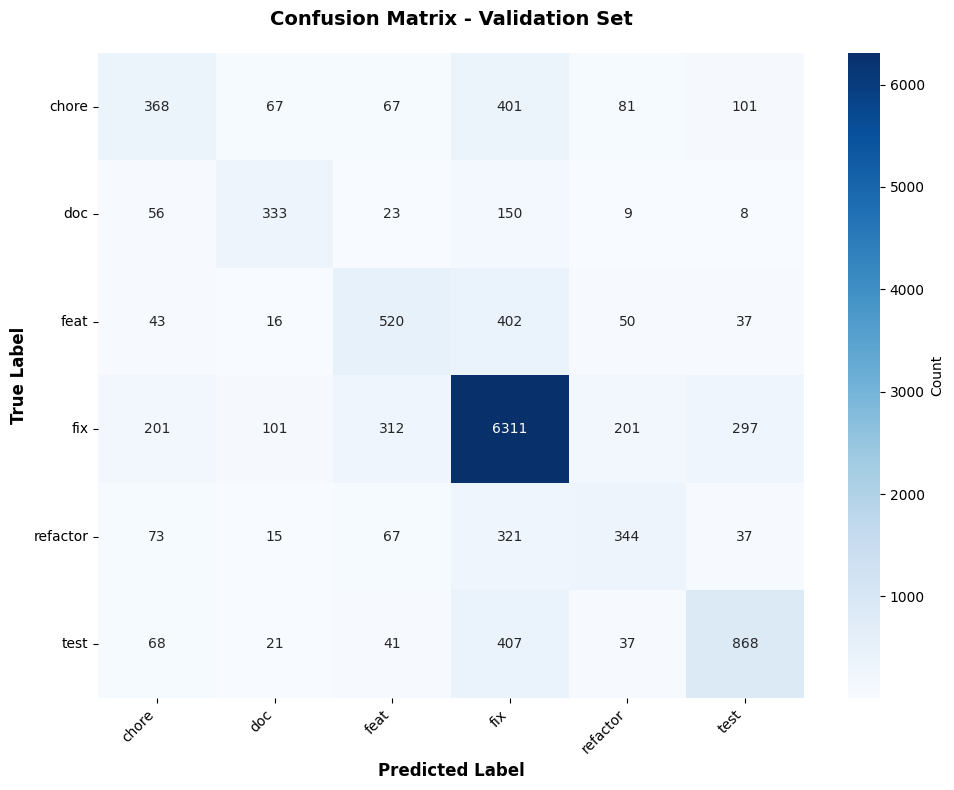

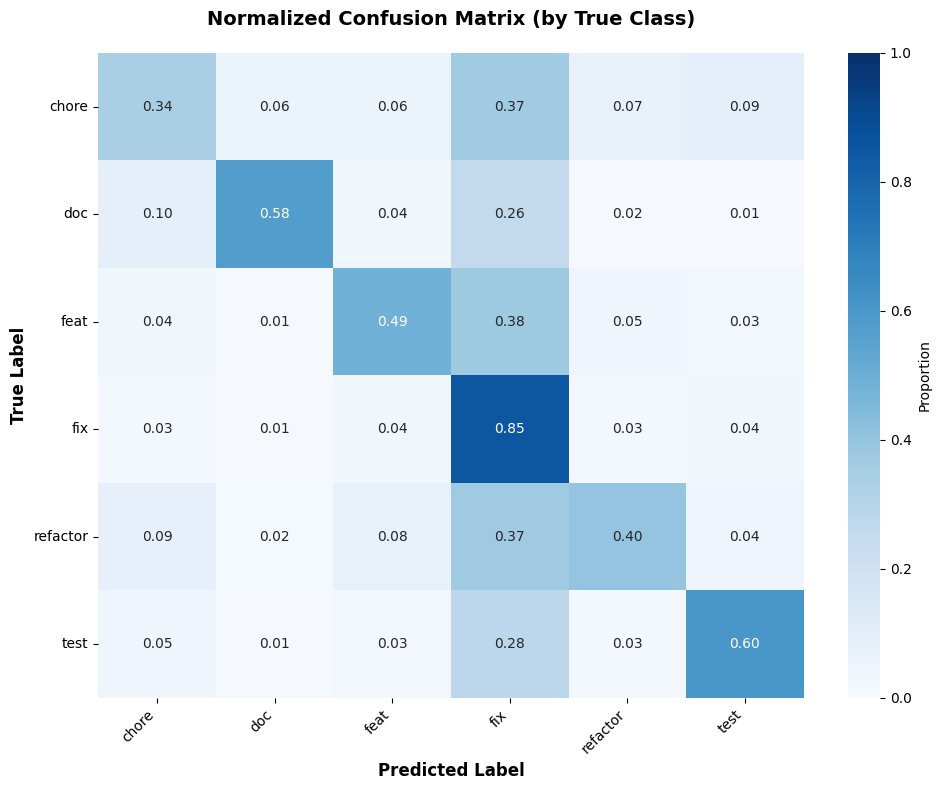


TOP CONFUSION PAIRS (excluding diagonal)

Top 10 most common misclassifications:
1. True: test       → Predicted: fix        | Count:  407 | 28.2% of true class
2. True: feat       → Predicted: fix        | Count:  402 | 37.6% of true class
3. True: chore      → Predicted: fix        | Count:  401 | 37.0% of true class
4. True: refactor   → Predicted: fix        | Count:  321 | 37.5% of true class
5. True: fix        → Predicted: feat       | Count:  312 | 4.2% of true class
6. True: fix        → Predicted: test       | Count:  297 | 4.0% of true class
7. True: fix        → Predicted: chore      | Count:  201 | 2.7% of true class
8. True: fix        → Predicted: refactor   | Count:  201 | 2.7% of true class
9. True: doc        → Predicted: fix        | Count:  150 | 25.9% of true class
10. True: chore      → Predicted: test       | Count:  101 | 9.3% of true class

Done!


In [ ]:
run(MODEL_PATH=BASELINE_MODEL_PATH, dataset_path='/content/drive/MyDrive/CS533: NLP/test_dataset.csv')

Using device: cuda
Validation set size: 12454

Class distribution:
result_class
fix         7423
test        1442
chore       1085
feat        1068
refactor     857
doc          579
Name: count, dtype: int64

Loading model from: /content/drive/MyDrive/CS533: NLP/codebert_icf


Loading weights:   0%|          | 0/201 [00:03<?, ?it/s]


Label mapping:
  0: chore
  1: doc
  2: feat
  3: fix
  4: refactor
  5: test


Map:   0%|          | 0/12454 [00:00<?, ? examples/s]


Generating predictions...
Generated 12454 predictions
CLASSIFICATION REPORT
              precision    recall  f1-score   support

       chore     0.3305    0.4295    0.3735      1085
         doc     0.4713    0.6805    0.5569       579
        feat     0.3448    0.6573    0.4523      1068
         fix     0.8898    0.5774    0.7003      7423
    refactor     0.3137    0.5589    0.4018       857
        test     0.5328    0.6755    0.5957      1442

    accuracy                         0.5862     12454
   macro avg     0.4805    0.5965    0.5134     12454
weighted avg     0.6939    0.5862    0.6113     12454

CONFUSION MATRIX

Raw counts:
[[ 466  102  130  111  153  123]
 [  54  394   37   52   24   18]
 [  75   24  702  107  114   46]
 [ 612  261  975 4286  664  625]
 [  92   26  108  110  479   42]
 [ 111   29   84  151   93  974]]


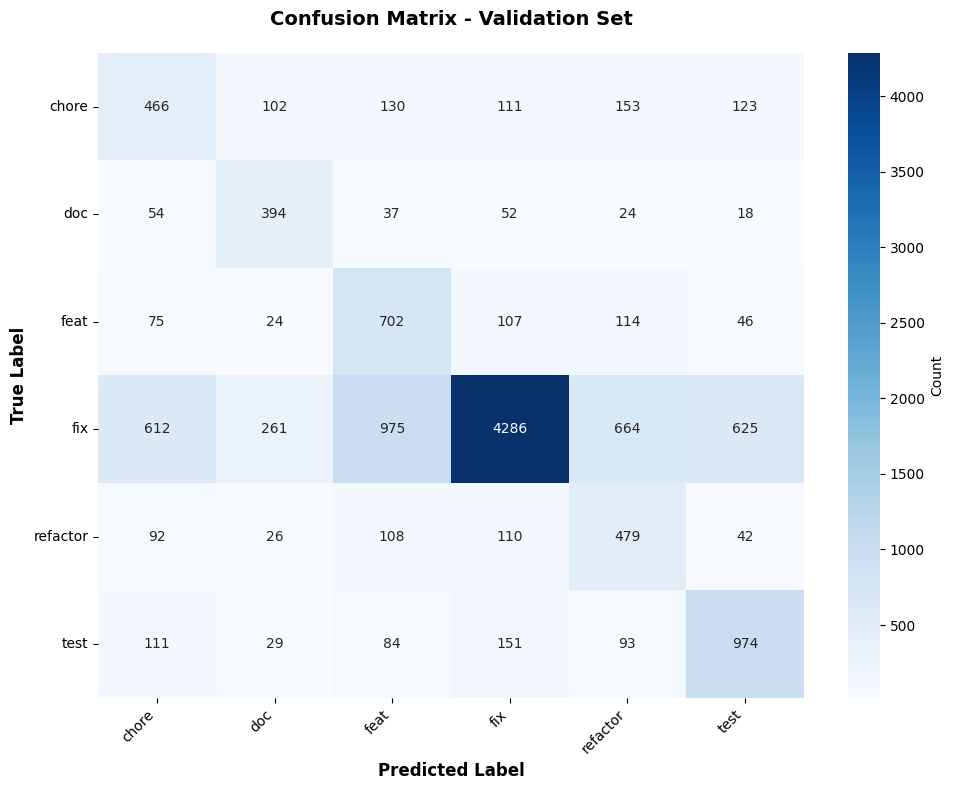

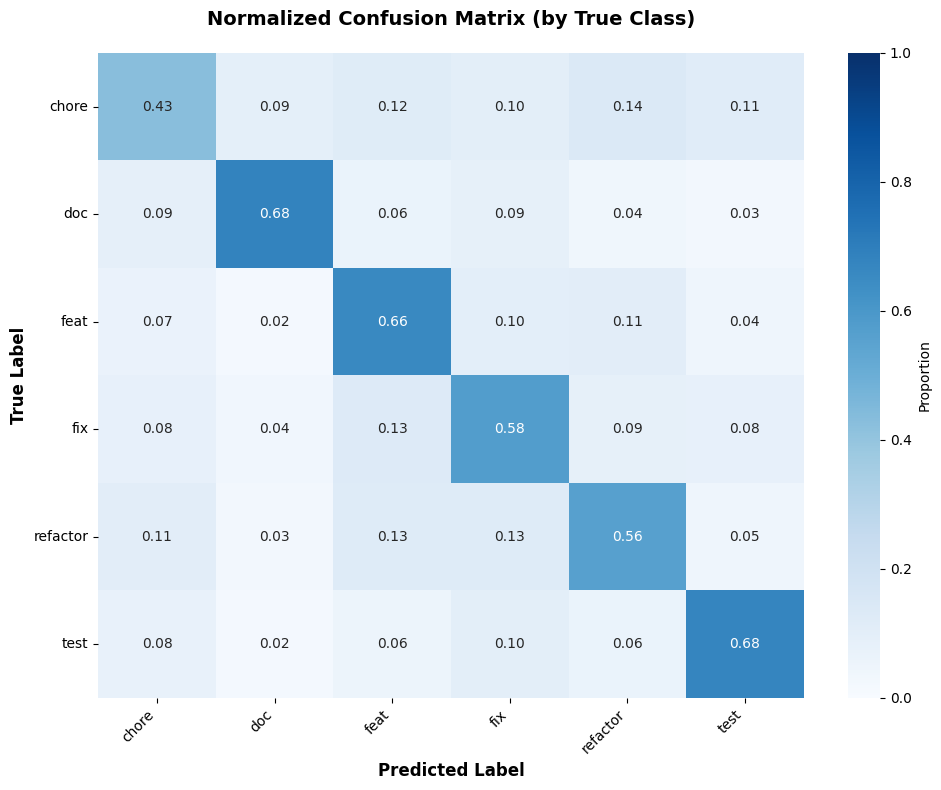


TOP CONFUSION PAIRS (excluding diagonal)

Top 10 most common misclassifications:
1. True: fix        → Predicted: feat       | Count:  975 | 13.1% of true class
2. True: fix        → Predicted: refactor   | Count:  664 | 8.9% of true class
3. True: fix        → Predicted: test       | Count:  625 | 8.4% of true class
4. True: fix        → Predicted: chore      | Count:  612 | 8.2% of true class
5. True: fix        → Predicted: doc        | Count:  261 | 3.5% of true class
6. True: chore      → Predicted: refactor   | Count:  153 | 14.1% of true class
7. True: test       → Predicted: fix        | Count:  151 | 10.5% of true class
8. True: chore      → Predicted: feat       | Count:  130 | 12.0% of true class
9. True: chore      → Predicted: test       | Count:  123 | 11.3% of true class
10. True: feat       → Predicted: refactor   | Count:  114 | 10.7% of true class

Done!


In [ ]:
run(MODEL_PATH=WEIGHTED_MODEL_PATH, dataset_path='/content/drive/MyDrive/CS533: NLP/test_dataset.csv')

# Effects of Inverse Class Frequency

Examining the classification report when finetuning CodeBERT without any class imbalance handling on the test set, we can see that the **fix** class (which heavily dominates the others) have a high precision rate of 0.79 and recall of 0.85, while the other classes have relatively low recall late. The model is conservative: when it predicts something, it's often right, but it misses many examples (low recall). Since the dataset is heavily skewed with **fix**, the model is biased toward that class and will often predict **fix** when its confidence is low about the other classes like **doc** or **refactor**.


Inverse Class Frequency (ICF) is a class balancing technique that gives more weight to the minority classes and penalizes the model more heavily if it predicts wrongly on these classes. When incorporating this technique into our fine-tuned CodeBERT, we observe a shift: There is a massive gain in the recall rates in the minority classes. For instance, when evaluating on the test set:
* doc: recall jumps from 0.57 → 0.65
* feat: recall jumps from 0.48 → 0.65
* refactor: recall jumps from 0.40 → 0.55
* chore: recall jumps from 0.34 → 0.43

We can examine the dominating class, **fix** more closely:
* Standard CodeBERT: precision 0.79, recall 0.85
* CodeBERT + ICF: precision 0.89, recall 0.57

The recall rate drops significantly, which means the weighted model learned to stop over-predicting **fix** (hence higher precision), which freed it up to predict minority classes more often (hence their higher recall). The loss function penalized **fix** mistakes less, so the model became pickier about calling something a **fix**.

An interesting thing to note is that the overall accuracy and F1 macro drops after incorporating ICF. However, this is misleading. What essentially happened is that there is a redistribution in the recall + precision rates from the majority class to minority classes. ICF rebalances the model's attention and ultimately demonstrates that there is a trade-off when involving a class balancing technique: If you care more about high recall (not missing minority-class), use ICF. If you care more about being confident in your predictions (high precision), consider other alternatives.

# Error analysis:

##Confusion Matrices: which classes get confused with each other most often, and why?

The most confusing pair for the baseline CodeBERT model is predicting **test** when the true class is **fix**, happening about 28% of the true class. In addition, when inspecting the **Predicted** column, **fix** dominates the frequency. This is intuitive; since there is a huge class imbalance, the model is less able to differentiate the different task between a fix and feat commit.  

However, when we incorporate ICF into CodeBERT, we see a more even distribution of predictions between different classes (feat, refactor, test, chore, doc -> more inclusive). The model now predicts **feat** instead of **fix**, the driving factor for class imbalance, about 13% of the true class, which suggests that CodeBERT + ICF does not weight **fix** as heavily as before, instead opting for other classes when making a prediction. This action emphasizes the benefits of ICF. It redistributes the evaluation metrics by lowering, or "stealing," the recall rate of the dominating class and give them to the underrepresented, resulting in a more balanced output.



# Analysis #2

In [ ]:
def get_predictions(model_path, df):
    """Load model and get predictions on validation set"""
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Load model and tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.to(device)
    model.eval()

    # Get label mappings
    id2label = model.config.id2label
    label2id = model.config.label2id

    # Prepare data
    df_copy = df.copy()
    df_copy['label'] = df_copy['result_class'].map(label2id)

    # Tokenize
    def tokenize_function(examples):
        return tokenizer(
            examples['message'],
            padding='max_length',
            truncation=True,
            max_length=MAX_LENGTH
        )

    dataset = Dataset.from_pandas(df_copy[['message', 'label']])
    dataset = dataset.map(tokenize_function, batched=True)
    dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

    # Get predictions
    all_predictions = []

    with torch.no_grad():
        for i in range(len(dataset)):
            inputs = {
                'input_ids': dataset[i]['input_ids'].unsqueeze(0).to(device),
                'attention_mask': dataset[i]['attention_mask'].unsqueeze(0).to(device)
            }
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=-1).item()
            all_predictions.append(id2label[pred])

    return all_predictions, id2label

In [ ]:
baseline_preds, id2label = get_predictions(BASELINE_MODEL_PATH, test_df)

weighted_preds, _ = get_predictions(WEIGHTED_MODEL_PATH, test_df)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/12454 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/12454 [00:00<?, ? examples/s]

In [ ]:
SAMPLE_SIZE = 5

# Add predictions to dataframe
test_df['baseline_pred'] = baseline_preds
test_df['weighted_pred'] = weighted_preds

# Identify errors
test_df['baseline_correct'] = test_df['result_class'] == test_df['baseline_pred']
test_df['weighted_correct'] = test_df['result_class'] == test_df['weighted_pred']

# SAMPLE ERRORS FROM EACH MODEL

baseline_errors = test_df[~test_df['baseline_correct']].copy()
weighted_errors = test_df[~test_df['weighted_correct']].copy()

print(f"\n{'='*70}")
print(f"ERROR STATISTICS")
print(f"{'='*70}")
print(f"Baseline errors: {len(baseline_errors)} / {len(test_df)} ({len(baseline_errors)/len(test_df)*100:.1f}%)")
print(f"Weighted errors: {len(weighted_errors)} / {len(test_df)} ({len(weighted_errors)/len(test_df)*100:.1f}%)")

# Sample errors (or take all if fewer than SAMPLE_SIZE)
baseline_sample = baseline_errors.sample(n=min(SAMPLE_SIZE, len(baseline_errors)), random_state=42)
weighted_sample = weighted_errors.sample(n=min(SAMPLE_SIZE, len(weighted_errors)), random_state=42)

# DISPLAY BASELINE MODEL ERRORS

print(f"\n{'='*70}")
print(f"BASELINE CODEBERT MODEL - SAMPLE OF MISCLASSIFIED EXAMPLES")
print(f"{'='*70}\n")

for idx, row in baseline_sample.iterrows():
    print(f"Example {idx}:")
    print(f"  Message: \"{row['message']}\"")
    print(f"  True label: {row['result_class']}")
    print(f"  Predicted: {row['baseline_pred']}")
    print(f"  Original tag: {row['original_tag']}")
    print()

# DISPLAY WEIGHTED MODEL ERRORS

print(f"\n{'='*70}")
print(f"CODEBERT + ICF MODEL - SAMPLE OF MISCLASSIFIED EXAMPLES")
print(f"{'='*70}\n")

for idx, row in weighted_sample.iterrows():
    print(f"Example {idx}:")
    print(f"  Message: \"{row['message']}\"")
    print(f"  True label: {row['result_class']}")
    print(f"  Predicted: {row['weighted_pred']}")
    print(f"  Original tag: {row['original_tag']}")
    print()

# FIND EXAMPLES BOTH MODELS GOT WRONG

both_wrong = test_df[~test_df['baseline_correct'] & ~test_df['weighted_correct']].copy()

print(f"\n{'='*70}")
print(f"BOTH MODELS WRONG - GENUINELY DIFFICULT CASES")
print(f"{'='*70}")
print(f"Count: {len(both_wrong)} examples\n")

both_wrong_sample = both_wrong.sample(n=min(15, len(both_wrong)), random_state=42)

for idx, row in both_wrong_sample.iterrows():
    print(f"Example {idx}:")
    print(f"  Message: \"{row['message']}\"")
    print(f"  True label: {row['result_class']}")
    print(f"  Baseline predicted: {row['baseline_pred']}")
    print(f"  Weighted predicted: {row['weighted_pred']}")
    print()

# FIND DISAGREEMENTS - ONE RIGHT, ONE WRONG

baseline_right_weighted_wrong = test_df[test_df['baseline_correct'] & ~test_df['weighted_correct']].copy()
weighted_right_baseline_wrong = test_df[~test_df['baseline_correct'] & test_df['weighted_correct']].copy()

print(f"\n{'='*70}")
print(f"MODEL DISAGREEMENTS")
print(f"{'='*70}")
print(f"Baseline correct, Weighted wrong: {len(baseline_right_weighted_wrong)}")
print(f"Weighted correct, Baseline wrong: {len(weighted_right_baseline_wrong)}")

if len(weighted_right_baseline_wrong) > 0:
    print(f"\nExamples where WEIGHTED model succeeded but BASELINE failed:")
    print(f"(Shows ICF helping minority classes)\n")

    sample = weighted_right_baseline_wrong.sample(n=min(10, len(weighted_right_baseline_wrong)), random_state=42)
    for idx, row in sample.iterrows():
        print(f"  Message: \"{row['message']}\"")
        print(f"  True: {row['result_class']} | Baseline: {row['baseline_pred']} ✗ | Weighted: {row['weighted_pred']} ✓")
        print()

if len(baseline_right_weighted_wrong) > 0:
    print(f"\nExamples where BASELINE model succeeded but WEIGHTED failed:")
    print(f"(Shows cost of ICF - often 'fix' class)\n")

    sample = baseline_right_weighted_wrong.sample(n=min(10, len(baseline_right_weighted_wrong)), random_state=42)
    for idx, row in sample.iterrows():
        print(f"  Message: \"{row['message']}\"")
        print(f"  True: {row['result_class']} | Baseline: {row['baseline_pred']} ✓ | Weighted: {row['weighted_pred']} ✗")
        print()


ERROR STATISTICS
Baseline errors: 3710 / 12454 (29.8%)
Weighted errors: 5153 / 12454 (41.4%)

BASELINE CODEBERT MODEL - SAMPLE OF MISCLASSIFIED EXAMPLES

Example 6096:
  Message: "wrong return decl for void method removed"
  True label: doc
  Predicted: fix
  Original tag: doc

Example 3607:
  Message: "improve cdata escaping related to bpmn-io/bpmn-moddle"
  True label: fix
  Predicted: test
  Original tag: fix

Example 3857:
  Message: "fix click delay for ios pwas"
  True label: feat
  Predicted: fix
  Original tag: feat

Example 2709:
  Message: "corrected the dev website server so that redirects are not cached"
  True label: doc
  Predicted: fix
  Original tag: docs

Example 2737:
  Message: "use a more specific type in docblocks"
  True label: fix
  Predicted: refactor
  Original tag: fix


CODEBERT + ICF MODEL - SAMPLE OF MISCLASSIFIED EXAMPLES

Example 10616:
  Message: "add missing taskpermissions reference related to cam-<i>"
  True label: chore
  Predicted: fix
  Original t

# Cases where ICF helps vs not and Inherent ambuigity

There are some examples where having a class balancing technique like ICF helps, such as these following cases:

* Message: "add epilogue to the help command"

  True: doc | Baseline: fix | Weighted: doc

* Message: "pass field name in form validation functions"

  True: feat | Baseline: fix  | Weighted: feat  

* Message: "remove error-silencing try/catch on event handler imports"

  True: refactor | Baseline: fix  | Weighted: refactor

* Message: "cleanup select for unlockheldlocks based on feedback from jon clean this up a bit."

  True: refactor | Baseline: fix | Weighted: refactor

The baseline CodeBERT predicts **fix** for many data points, even though the action does not correlate with the description. Therefore, ICF helps classify **refactor** or **feat** where necessary.

With CodeBERT + ICF producing a more even distribution of output classes, there are cases where ICF does not predict the true class **fix** when it needs to (a natural consequence & trade-off when utilizing such technique):

* Message: "specific examples caused a trivial compiler bug"
  
  True: fix | Baseline: fix | Weighted: doc

*  Message: "fix check for null or undefined value affects: @crave/farmblocks-search-field"

  True: fix | Baseline: fix  | Weighted: test

Although, there are also cases where both models get it wrong:

* Message: add missing "get_content_model" query

  True label: test | Baseline predicted: fix | Weighted predicted: fix

*   Message: "status's cause is not transmitted from server to client"

  True label: doc | Baseline predicted: fix | Weighted predicted: fix

* Message: "add more constraint on logo during role edition"
  
  True label: refactor | Baseline predicted: feat | Weighted predicted: feat

* Message: "error message should be plural"

  True label: doc | Baseline predicted: fix | Weighted predicted: fix


This problem can be attributed to several reasons:
* The data point is mislabeled because the commit message refers to an action of another type. For example, the message "add more constraint on logo during role edition" should be labelled as a **feat**, not **refactor**.

* Some messages are simply not sufficient on its own to determine the type of action and need more context. For instance, it's hard to tell whether the message "status's cause is not transmitted from server to client" or "use bound method in number#topaddedstring" refer to **fix**, **feat**, **refactor**, or something else. As a result, this is a drawback of solely relying on commit messages. It can cause ambuigity due to lack context and lead to a mislabelled result. Future works can include incorporating code diffs or file paths into the model to get a clearer picture before classification.

# Analysis #3

# Examining variances between the orignal tag vs. merged tag (data points that are labelled as bugfix/fixed/bug have been merged into fix): Is our merging method justifiable?



In [ ]:
all_predictions, _ = get_predictions(WEIGHTED_MODEL_PATH, test_df)

test_df['predicted'] = all_predictions
test_df['correct'] = test_df['result_class'] == test_df['predicted']

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/12454 [00:00<?, ? examples/s]

Merged class mappings:
  fix: ['fix', 'bugfix', 'fixed', 'bug']
  test: ['test', 'tests', 'tst']
  feat: ['feat', 'enh']
  chore: ['chore', 'maint']

WITHIN-CLASS VARIANCE ANALYSIS


FIX:
  Variants tested: ['fix', 'bugfix', 'fixed', 'bug']
  Accuracy range: 0.2469 (variance: 0.0103)
  HIGH VARIANCE - original tag matters significantly
      Best: 'fixed' (0.7939)
      Worst: 'fix' (0.5469)

TEST:
  Variants tested: ['test', 'tests']
  Accuracy range: 0.0321 (variance: 0.0003)
  LOW VARIANCE - merging had minimal impact


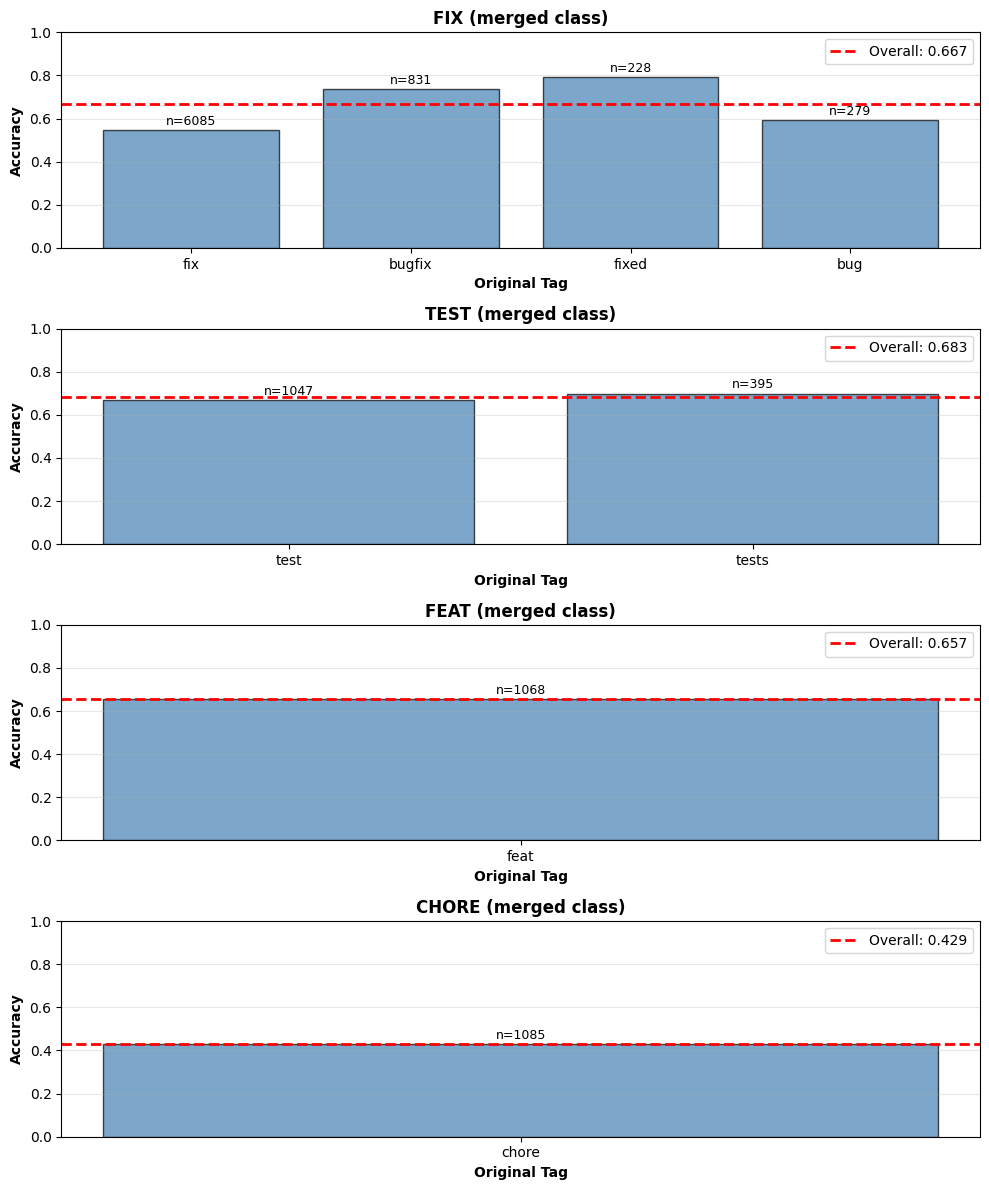

In [ ]:
# DEFINE MERGED CLASS MAPPINGS

# Define which original tags map to which merged class
merged_mapping = {
    'fix': ['fix', 'bugfix', 'fixed', 'bug'],
    'test': ['test', 'tests', 'tst'],
    'feat': ['feat', 'enh'],
    'chore': ['chore', 'maint']
}

# Create reverse mapping (original_tag -> merged_class)
original_to_merged = {}
for merged_class, original_tags in merged_mapping.items():
    for tag in original_tags:
        original_to_merged[tag] = merged_class

print(f"Merged class mappings:")
for merged_class, original_tags in merged_mapping.items():
    print(f"  {merged_class}: {original_tags}")

results = []

for merged_class, original_tags in merged_mapping.items():

    # Get all examples for this merged class
    merged_class_df = test_df[test_df['result_class'] == merged_class]


    # Overall performance for the merged class
    overall_accuracy = merged_class_df['correct'].mean()

    # Performance by each original tag variant
    for original_tag in original_tags:
        tag_df = merged_class_df[merged_class_df['original_tag'] == original_tag]

        if len(tag_df) == 0:
            continue

        tag_accuracy = tag_df['correct'].mean()
        tag_count = len(tag_df)
        tag_correct = tag_df['correct'].sum()

        # Calculate how this variant compares to overall
        diff_from_overall = tag_accuracy - overall_accuracy

        results.append({
            'merged_class': merged_class,
            'original_tag': original_tag,
            'count': tag_count,
            'correct': tag_correct,
            'accuracy': tag_accuracy,
            'diff_from_overall': diff_from_overall
        })

results_df = pd.DataFrame(results)

# STATISTICAL COMPARISON WITHIN MERGED CLASSES

print(f"\n{'='*70}")
print(f"WITHIN-CLASS VARIANCE ANALYSIS")
print(f"{'='*70}\n")

for merged_class, original_tags in merged_mapping.items():
    class_results = results_df[results_df['merged_class'] == merged_class]

    # Need at least 2 variants with sufficient examples
    class_results_significant = class_results[class_results['count'] >= 10]

    if len(class_results_significant) < 2:
        continue

    print(f"\n{merged_class.upper()}:")

    accuracies = class_results_significant['accuracy'].values
    tags = class_results_significant['original_tag'].values

    variance = np.var(accuracies)
    accuracy_range = np.max(accuracies) - np.min(accuracies)

    print(f"  Variants tested: {list(tags)}")
    print(f"  Accuracy range: {accuracy_range:.4f} (variance: {variance:.4f})")

    if accuracy_range > 0.1:
        print(f"  HIGH VARIANCE - original tag matters significantly")
        best = class_results_significant.loc[class_results_significant['accuracy'].idxmax()]
        worst = class_results_significant.loc[class_results_significant['accuracy'].idxmin()]
        print(f"      Best: '{best['original_tag']}' ({best['accuracy']:.4f})")
        print(f"      Worst: '{worst['original_tag']}' ({worst['accuracy']:.4f})")
    else:
        print(f"  LOW VARIANCE - merging had minimal impact")

# VISUALIZE PERFORMANCE BY ORIGINAL TAG

if len(results_df) > 0:
    # Create visualization for merged classes with multiple variants
    fig, axes = plt.subplots(
        len(merged_mapping), 1,
        figsize=(10, 3 * len(merged_mapping)),
        squeeze=False
    )

    for idx, (merged_class, original_tags) in enumerate(merged_mapping.items()):
        ax = axes[idx, 0]

        class_results = results_df[results_df['merged_class'] == merged_class]

        if len(class_results) == 0:
            ax.text(0.5, 0.5, f'No data for {merged_class}',
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{merged_class} (merged class)')
            continue

        # Create bar plot
        x = class_results['original_tag'].values
        y = class_results['accuracy'].values
        counts = class_results['count'].values

        bars = ax.bar(x, y, color='steelblue', alpha=0.7, edgecolor='black')

        # Add overall accuracy line
        overall_acc = class_results['accuracy'].mean()
        ax.axhline(y=overall_acc, color='red', linestyle='--',
                  label=f'Overall: {overall_acc:.3f}', linewidth=2)

        # Add count labels on bars
        for bar, count in zip(bars, counts):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'n={count}', ha='center', va='bottom', fontsize=9)

        ax.set_ylabel('Accuracy', fontweight='bold')
        ax.set_xlabel('Original Tag', fontweight='bold')
        ax.set_title(f'{merged_class.upper()} (merged class)', fontweight='bold')
        ax.set_ylim(0, 1.0)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

In this section, we examine the effects of our merging method. Was merging bugfix, fixed, bug into fix a good strategy? What about "chore" and "maint" into "chore"? Within each class, we calculate the accuracy of each original tag and then calculate their variances. Upon examination of the figures, we can see that the **fix** class has the highest variance, with accuracies fluctuating up to 25%. While this is not necessarily bad since the semantics of bugfix, fixed, bug, and fix all sound pretty similar on the surface, this result suggests that developers use these tags in systematically different contexts — possibly based on bug severity, commit scope, or team conventions — that aren't captured in the commit message text alone. This variance represents label noise introduced by our merging strategy, which likely caps our model's achievable accuracy on this class.

On the other hand, the class "Test," 'test', 'tests', 'tst' had accuracies differences of only 3% (and variance of 0.0003), demonstrating that their original and merged tags had the same semantic meanings and our decision to merge them together was justified. Ultimately, these analysis comes down to the curation of the dataset and the quality of the commit message that was collected.  